## Correlating EOP to defense genes, AMR profiles and AMR genes

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import numpy as np
from statsmodels.stats.multitest import multipletests

### Defense systems with EOP

In [ ]:
#read files
defense_systems = pd.read_excel("TableS3-defenseSystems.xlsx")
eop_values = pd.read_csv("EOP_values.csv")

eop_long = eop_values.melt(id_vars=["EOP"], var_name="bacteria", value_name="EOP_value")
eop_long['EOP_value'] = pd.to_numeric(eop_long['EOP_value'], errors='coerce').fillna(0)

# Standardize bacteria names in eop_long to match defense_systems
eop_long['bacteria'] = eop_long['bacteria'].str.replace('A ', 'A. ')

defense_presence = (
    defense_systems.groupby(["bacteria", "subtype"]).size().reset_index(name="present"))
defense_presence["present"] = 1

defense_matrix = (
    defense_presence.pivot(index="bacteria", columns="subtype", values="present")
    .fillna(0)
    .reset_index()
)


# Merge EOP values with defense system presence/absence matrix
merged_eop_defense = pd.merge(eop_long, defense_matrix, on='bacteria', how='left')

# Fill NaNs in defense subtype columns after merging
defense_subtypes = [s for s in defense_systems["subtype"].unique() if pd.notna(s)]
merged_eop_defense[defense_subtypes] = merged_eop_defense[defense_subtypes].fillna(0)
merged_eop_defense

,EOP,bacteria,EOP_value,AbiU,CBASS_II,CBASS_III,Hna,Kiwa,PD-T7-1,RM_Type_I,RM_Type_II,Shedu
0,Coliflower,A. xylosoxidans jini,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,Infector,A. xylosoxidans jini,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,Yaccob,A. xylosoxidans jini,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,Rage,A. xylosoxidans jini,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,Patchman,A. xylosoxidans jini,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
100,ewik,A. insolitus cram,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
101,maay,A. insolitus cram,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
102,shaaii,A. insolitus cram,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
103,nyashin,A. insolitus cram,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
# Calculate correlation between EOP_value and each defense subtype
correlation_results = []
for subtype in defense_subtypes:
    if merged_eop_defense['EOP_value'].nunique() > 1 and merged_eop_defense[subtype].nunique() > 1:
        rho, p_value = spearmanr(merged_eop_defense['EOP_value'], merged_eop_defense[subtype])
        correlation_results.append({
            'defense_subtype': subtype,
            'spearman_rho': rho,
            'p_value': p_value
        })

correlation_df = pd.DataFrame(correlation_results)
correlation_df

,defense_subtype,spearman_rho,p_value
0,Hna,-0.132521,0.177778
1,AbiU,0.162639,0.097386
2,RM_Type_II,0.087981,0.372136
3,RM_Type_I,0.162639,0.097386
4,PD-T7-1,0.162639,0.097386
5,CBASS_II,0.280440,0.003760
6,Kiwa,0.027494,0.780697
7,Shedu,0.164965,0.092628
8,CBASS_III,-0.203456,0.037372


In [ ]:
# ----- MULTIPLE TESTING CORRECTION (Benjamini–Hochberg FDR) -----
if not correlation_df.empty:
    reject, p_adj, _, _ = multipletests(correlation_df['p_value'], method='fdr_bh')
    correlation_df['p_adj'] = p_adj
    correlation_df['significant'] = reject   # this is FDR-adjusted significance at alpha=0.05
else:
    # If correlation_df is empty, ensure it has all expected columns to prevent KeyError later
    correlation_df = pd.DataFrame(columns=['defense_subtype', 'spearman_rho', 'p_value', 'p_adj', 'significant'])

defense_corr_df = correlation_df
defense_corr_df


,defense_subtype,spearman_rho,p_value,p_adj,significant
0,Hna,-0.132521,0.177778,0.228572,False
1,AbiU,0.162639,0.097386,0.146080,False
2,RM_Type_II,0.087981,0.372136,0.418653,False
3,RM_Type_I,0.162639,0.097386,0.146080,False
4,PD-T7-1,0.162639,0.097386,0.146080,False
5,CBASS_II,0.280440,0.003760,0.033838,True
6,Kiwa,0.027494,0.780697,0.780697,False
7,Shedu,0.164965,0.092628,0.146080,False
8,CBASS_III,-0.203456,0.037372,0.146080,False


In [ ]:
bact_df

,bacteria,EOP_value,Hna,AbiU,RM_Type_II,RM_Type_I,PD-T7-1,CBASS_II,Kiwa,Shedu,CBASS_III
0,A. insolitus aura,0.400000,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
1,A. insolitus cram,0.266667,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,A. insolitus neet,0.400000,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
3,A. insolitus vya,1.000000,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,A. xylosoxidans ayb,0.600000,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
5,A. xylosoxidans jini,0.200000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,A. xylosoxidans suz,0.666667,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
#Aggregate EOP at the bacterium level first, since each bacteria is repeated 15 times for each phage.
#So correcting for this
bact_df = (
    merged_eop_defense
    .groupby("bacteria")
    .agg({
        "EOP_value": "mean",
        **{s: "first" for s in defense_subtypes}
    })
    .reset_index()
)

from scipy.stats import spearmanr

results = []

for subtype in defense_subtypes:
    rho, p = spearmanr(
        bact_df["EOP_value"],
        bact_df[subtype]
    )
    results.append([subtype, rho, p])

correlation_df_corr = pd.DataFrame(
    results,
    columns=["defense_subtype", "rho", "p"]
)
correlation_df_corr

,defense_subtype,rho,p
0,Hna,-0.319090,0.485448
1,AbiU,0.478634,0.277227
2,RM_Type_II,0.364110,0.422015
3,RM_Type_I,0.478634,0.277227
4,PD-T7-1,0.478634,0.277227
5,CBASS_II,0.509753,0.242521
6,Kiwa,0.000000,1.000000
7,Shedu,0.291288,0.526204
8,CBASS_III,-0.291288,0.526204


In [ ]:
# ----- MULTIPLE TESTING CORRECTION (Benjamini–Hochberg FDR) -----
if not correlation_df_corr.empty:
    reject, p_adj, _, _ = multipletests(correlation_df_corr['p'], method='fdr_bh')
    correlation_df_corr['p_adj'] = p_adj
    correlation_df_corr['significant'] = reject   # this is FDR-adjusted significance at alpha=0.05
else:
    # If correlation_df is empty, ensure it has all expected columns to prevent KeyError later
    correlation_df_corr = pd.DataFrame(columns=['defense_subtype', 'spearman_rho', 'p_value', 'p_adj', 'significant'])

defense_corr_df_corr = correlation_df_corr
defense_corr_df_corr


,defense_subtype,rho,p,p_adj,significant
0,Hna,-0.319090,0.485448,0.591979,False
1,AbiU,0.478634,0.277227,0.591979,False
2,RM_Type_II,0.364110,0.422015,0.591979,False
3,RM_Type_I,0.478634,0.277227,0.591979,False
4,PD-T7-1,0.478634,0.277227,0.591979,False
5,CBASS_II,0.509753,0.242521,0.591979,False
6,Kiwa,0.000000,1.000000,1.000000,False
7,Shedu,0.291288,0.526204,0.591979,False
8,CBASS_III,-0.291288,0.526204,0.591979,False


### Antibiotic reistance genes

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests  # <--- NEW

amr = pd.read_csv("amrfinderplus_all.tsv", sep="\t", dtype=str).fillna("")

# ----------------------------
# 3️⃣ Count AMR genes by Class for each bacterium
# ----------------------------
# Identify relevant columns
if "Class" in amr.columns:
    class_col = "Class"
elif "Drug Class" in amr.columns:
    class_col = "Drug Class"
else:
    raise ValueError("Could not find a 'Class' column in your AMRFinderPlus file.")

# Detect bacterium column
if "sample" in amr.columns:
    bact_col = "sample"
elif "Isolate" in amr.columns:
    bact_col = "Isolate"
else:
    raise ValueError("Could not find a bacterium identifier column (e.g., 'Sequence name').")

# Create per-bacterium counts of each AMR class
amr_counts = (
    amr.groupby([bact_col, class_col])
       .size()
       .reset_index(name="count")
       .pivot(index=bact_col, columns=class_col, values="count")
       .fillna(0)
       .reset_index()
       .rename(columns={bact_col: "bacteria"})
)

# ----------------------------
# 4️⃣ Merge with EOP data
# ----------------------------
merged = eop_long.merge(amr_counts, on="bacteria", how="left").fillna(0)
merged["log10_EOP"] = np.log10(merged["EOP_value"] + 1e-9)

# ----------------------------
# 5️⃣ Compute Spearman correlations
# ----------------------------
correlation_results = []
for amr_class in amr_counts.columns[1:]:
    if merged[amr_class].nunique() > 1 and merged["EOP_value"].nunique() > 1:
        rho, p_value = spearmanr(
            merged["EOP_value"],
            merged[amr_class],
            nan_policy="omit"
        )
        correlation_results.append({
            "AMR_class": amr_class,
            "spearman_rho": rho,
            "p_value": p_value
        })

corr_df = pd.DataFrame(correlation_results)

# ----- MULTIPLE TESTING CORRECTION (Benjamini–Hochberg FDR) -----
if not corr_df.empty:
    reject, p_adj, _, _ = multipletests(corr_df["p_value"], method="fdr_bh")
    corr_df["p_adj"] = p_adj
    corr_df["significant"] = reject  # True/False at alpha=0.05
    corr_df = corr_df.sort_values("p_adj")
else:
    corr_df["p_adj"] = []
    corr_df["significant"] = []

amr_class_corr_df = corr_df

print("Spearman correlations: EOP vs AMR class counts")
display(corr_df)


Spearman correlations: EOP vs AMR class counts


,AMR_class,spearman_rho,p_value,p_adj,significant
4,TETRACYCLINE,0.373920,0.000085,0.000426,True
1,BETA-LACTAM,-0.277187,0.004201,0.010503,True
0,AMINOGLYCOSIDE,-0.236609,0.015094,0.025157,True
2,FOSFOMYCIN,-0.194413,0.046890,0.058612,False
3,PHENICOL,-0.090355,0.359323,0.359323,False


In [ ]:
# --------------------------------------------------
# Count AMR genes per class per bacterium
# --------------------------------------------------

amr_counts = (
    amr.groupby(["sample", "Class"])
       .size()
       .reset_index(name="count")
       .pivot(index="sample", columns="Class", values="count")
       .fillna(0)
       .reset_index()
       .rename(columns={"sample": "bacteria"})
)

# Add log10_EOP to eop_long before aggregation
eop_long["log10_EOP"] = np.log10(eop_long["EOP_value"] + 1e-9)

# --------------------------------------------------
# Calculate mean susceptibility for each bacterium
# --------------------------------------------------

bacteria_eop = (
    eop_long
    .groupby("bacteria", as_index=False)
    .agg(
        mean_log10_EOP=("log10_EOP", "mean"),
        median_log10_EOP=("log10_EOP", "median")
    )
)

# --------------------------------------------------
# Merge EOP and AMR profiles
# --------------------------------------------------

merged_bacteria = bacteria_eop.merge(
    amr_counts,
    on="bacteria",
    how="left"
).fillna(0)
# --------------------------------------------------
# Spearman correlations
# --------------------------------------------------

results = []

amr_classes = [
    c for c in merged_bacteria.columns
    if c not in ["bacteria", "mean_log10_EOP", "median_log10_EOP"]
]

for amr_class in amr_classes:

    if merged_bacteria[amr_class].nunique() < 2:
        continue

    rho, p = spearmanr(
        merged_bacteria["mean_log10_EOP"],
        merged_bacteria[amr_class]
    )

    results.append({
        "AMR_class": amr_class,
        "rho": rho,
        "p_value": p,
        "n_bacteria": len(merged_bacteria)
    })

corr_df_corr = pd.DataFrame(results)

# --------------------------------------------------
# FDR correction
# --------------------------------------------------
if len(corr_df_corr) > 0:

    reject, p_adj, _, _ = multipletests(
        corr_df_corr["p_value"],
        method="fdr_bh"
    )

    corr_df_corr["p_adj"] = p_adj
    corr_df_corr["significant"] = reject

corr_df_corr = corr_df_corr.sort_values(
    ["p_adj", "rho"],
    ascending=[True, False]
)

corr_df_corr

,AMR_class,rho,p_value,n_bacteria,p_adj,significant
4,TETRACYCLINE,0.801041,0.030369,7,0.151845,False
2,FOSFOMYCIN,-0.411943,0.358459,7,0.448074,False
0,AMINOGLYCOSIDE,-0.428174,0.337866,7,0.448074,False
1,BETA-LACTAM,-0.476731,0.279418,7,0.448074,False
3,PHENICOL,-0.159545,0.732582,7,0.732582,False


### Antibiotic phenotypes

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

# ---------- helper to normalise bacteria names (tweak as needed) ----------
def normalize_bacteria(name):
    if isinstance(name, str):
        # example: "A. xylosoxidans jini" -> "A xylosoxidans jini"
        return name.replace("A. ", "A ").strip()
    return name

# Load
eop = pd.read_csv("EOP_values.csv")
amr = pd.read_csv("amrresults.csv")

# --- 1. Reshape EOP to long format ---
eop_long = eop.melt(id_vars=["EOP"], var_name="bacteria", value_name="EOP_value")
eop_long["EOP_value"] = pd.to_numeric(eop_long["EOP_value"], errors="coerce").fillna(0)
eop_long["bacteria"] = eop_long["bacteria"].apply(normalize_bacteria)

# --- 2. Reshape AMR (wide → long) ---
amr_long = amr.melt(id_vars=["Antibiotic"], var_name="bacteria", value_name="resistance")
amr_long.rename(columns={"Antibiotic": "antibiotic"}, inplace=True)
amr_long["bacteria"] = amr_long["bacteria"].apply(normalize_bacteria)

# --- 3. Merge ---
merged = eop_long.merge(amr_long, on="bacteria", how="left")

# --- 4. Clean & convert R/S/I to numeric ---
mapping = {"R": 1, "S": 0, "I": 0.5}

merged["resistance_clean"] = (
    merged["resistance"]
    .astype(str)
    .str.strip()
    .str.upper()
)

merged["resistance_score"] = merged["resistance_clean"].map(mapping)

# optional: quick sanity check
print("Resistance values after cleaning:")
print(merged["resistance_clean"].value_counts().head())

# --- 5. Compute correlations ---
results = []
for abx in merged["antibiotic"].dropna().unique():
    sub = merged[merged["antibiotic"] == abx].copy()
    sub = sub.dropna(subset=["resistance_score"])  # drop NaNs from unknown codes

    if sub["resistance_score"].nunique() > 1 and sub["EOP_value"].nunique() > 1:
        rho, p = spearmanr(sub["EOP_value"], sub["resistance_score"], nan_policy='omit')
        results.append({"antibiotic": abx, "spearman_rho": rho, "p_value": p})

corr_df = pd.DataFrame(results)

# ----- MULTIPLE TESTING CORRECTION (Benjamini–Hochberg FDR) ---
if not corr_df.empty:
    reject, p_adj, _, _ = multipletests(corr_df["p_value"], method="fdr_bh")
    corr_df["p_adj"] = p_adj
    corr_df["significant"] = reject  # True/False at FDR alpha=0.05
    corr_df = corr_df.sort_values("p_adj")
else:
    corr_df["p_adj"] = []
    corr_df["significant"] = []

antibiotic_corr_df = corr_df

print("Spearman correlation: EOP vs antibiotic resistance (per antibiotic)")
display(antibiotic_corr_df)

Resistance values after cleaning:
resistance_clean
R    930
S    270
I     60
Name: count, dtype: int64
Spearman correlation: EOP vs antibiotic resistance (per antibiotic)


,antibiotic,spearman_rho,p_value,p_adj,significant
2,Ceftazidime,0.201590,0.039191,0.313525,False
0,Piperacillin/tazobactam,-0.132521,0.177778,0.357673,False
6,Tobramycin,-0.132201,0.178836,0.357673,False
7,Trimethoprim/sulfamethoxazole,0.132521,0.177778,0.357673,False
4,Amikacin,0.085542,0.385591,0.616946,False
1,Ticarcillin/ clavulanate,0.027494,0.780697,0.892225,False
3,Meropenem,0.027494,0.780697,0.892225,False
5,Gentamicin,-0.011879,0.904270,0.904270,False


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# --------------------------------------------------
# helper
# --------------------------------------------------

def normalize_bacteria(name):
    if isinstance(name, str):
        return name.replace("A. ", "A ").strip()
    return name

# --------------------------------------------------
# load
# --------------------------------------------------

eop = pd.read_csv("EOP_values.csv")
amr = pd.read_csv("amrresults.csv")

# --------------------------------------------------
# EOP long format
# --------------------------------------------------

eop_long = eop.melt(
    id_vars=["EOP"],
    var_name="bacteria",
    value_name="EOP_value"
)

eop_long["EOP_value"] = pd.to_numeric(
    eop_long["EOP_value"],
    errors="coerce"
)

eop_long["bacteria"] = eop_long["bacteria"].apply(normalize_bacteria)

eop_long["log10_EOP"] = np.log10(
    eop_long["EOP_value"] + 1e-9
)

# --------------------------------------------------
# mean susceptibility per bacterium
# --------------------------------------------------

bacteria_eop = (
    eop_long
    .groupby("bacteria", as_index=False)
    .agg(
        mean_log10_EOP=("log10_EOP", "mean")
    )
)

# --------------------------------------------------
# AMR phenotype long format
# --------------------------------------------------

amr_long = amr.melt(
    id_vars=["Antibiotic"],
    var_name="bacteria",
    value_name="resistance"
)

amr_long.rename(
    columns={"Antibiotic": "antibiotic"},
    inplace=True
)

amr_long["bacteria"] = (
    amr_long["bacteria"]
    .apply(normalize_bacteria)
)

mapping = {
    "S": 0,
    "I": 0.5,
    "R": 1
}

amr_long["resistance_score"] = (
    amr_long["resistance"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map(mapping)
)

# --------------------------------------------------
# merge
# --------------------------------------------------

merged = bacteria_eop.merge(
    amr_long,
    on="bacteria",
    how="left"
)

# --------------------------------------------------
# Spearman correlations
# --------------------------------------------------

results = []

for abx in merged["antibiotic"].dropna().unique():

    sub = merged[
        merged["antibiotic"] == abx
    ].copy()

    sub = sub.dropna(
        subset=["resistance_score"]
    )

    if len(sub) < 4:
        continue

    if (
        sub["resistance_score"].nunique() > 1
        and
        sub["mean_log10_EOP"].nunique() > 1
    ):

        rho, p = spearmanr(
            sub["mean_log10_EOP"],
            sub["resistance_score"]
        )

        results.append({
            "antibiotic": abx,
            "rho": rho,
            "p_value": p,
            "n_bacteria": len(sub)
        })

corr_df_corr2 = pd.DataFrame(results)

# --------------------------------------------------
# FDR correction
# --------------------------------------------------

if not corr_df_corr2.empty:

    reject, p_adj, _, _ = multipletests(
        corr_df_corr2["p_value"],
        method="fdr_bh"
    )

    corr_df_corr2["p_adj"] = p_adj
    corr_df_corr2["significant"] = reject

corr_df_corr2 = corr_df_corr2.sort_values(
    "p_adj"
)

display(corr_df_corr2)

,antibiotic,rho,p_value,n_bacteria,p_adj,significant
0,Piperacillin/tazobactam,-0.159545,0.732582,7,1.0,False
1,Ticarcillin/ clavulanate,0.000000,1.000000,7,1.0,False
2,Ceftazidime,0.333712,0.464484,7,1.0,False
3,Meropenem,0.000000,1.000000,7,1.0,False
4,Amikacin,0.102986,0.826092,7,1.0,False
5,Gentamicin,-0.179787,0.699693,7,1.0,False
6,Tobramycin,-0.411943,0.358459,7,1.0,False
7,Trimethoprim/sulfamethoxazole,0.319090,0.485448,7,1.0,False


### Visualising

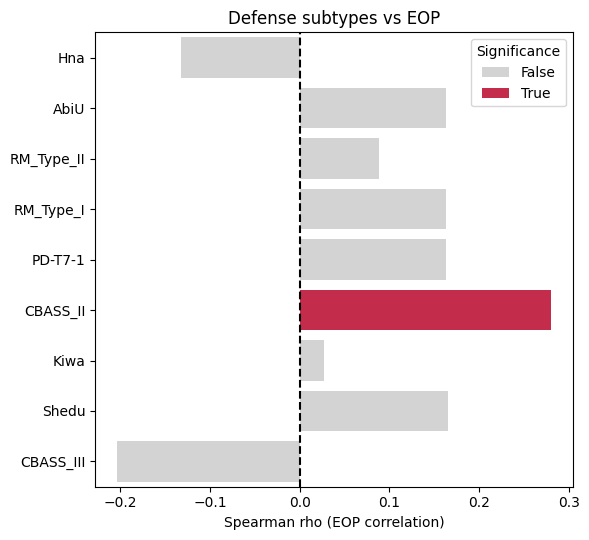

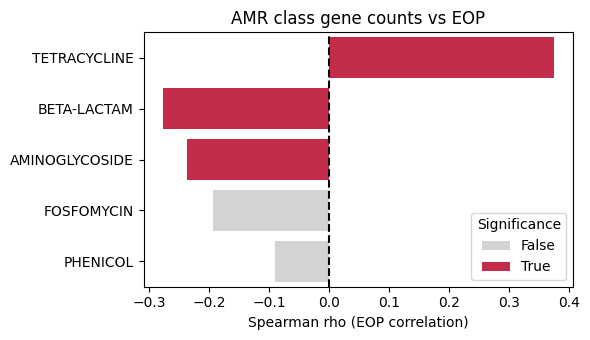

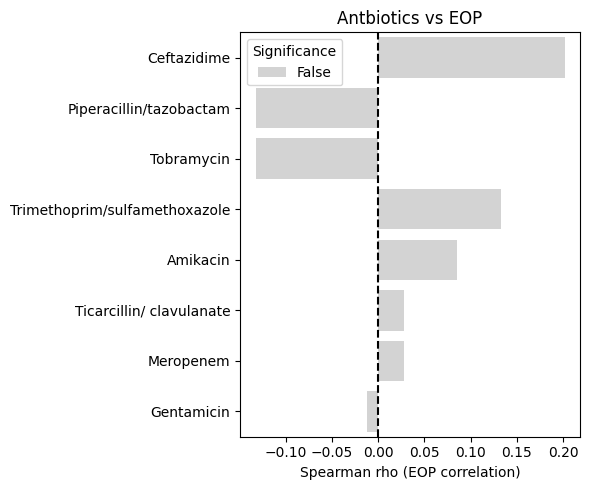

In [ ]:
#Visualising pre pesudo correction
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

def plot_correlations(df, feature_col, rho_col, p_col, title):
    df = df.copy()
    df["Significance"] = df[p_col] < 0.05
    plt.figure(figsize=(6, len(df)*0.5 + 1))
    sns.barplot(data=df, x=rho_col, y=feature_col, hue="Significance",
                palette={True: "crimson", False: "lightgrey"}, dodge=False)
    plt.axvline(0, color="black", linestyle="--")
    plt.title(title)
    plt.xlabel("Spearman rho (EOP correlation)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


plot_correlations(defense_corr_df, "defense_subtype", "spearman_rho", "p_adj",
                  "Defense subtypes vs EOP")

plot_correlations(amr_class_corr_df, "AMR_class", "spearman_rho", "p_adj",
                  "AMR class gene counts vs EOP")

plot_correlations(antibiotic_corr_df, "antibiotic", "spearman_rho", "p_adj",
                  "Antbiotics vs EOP")

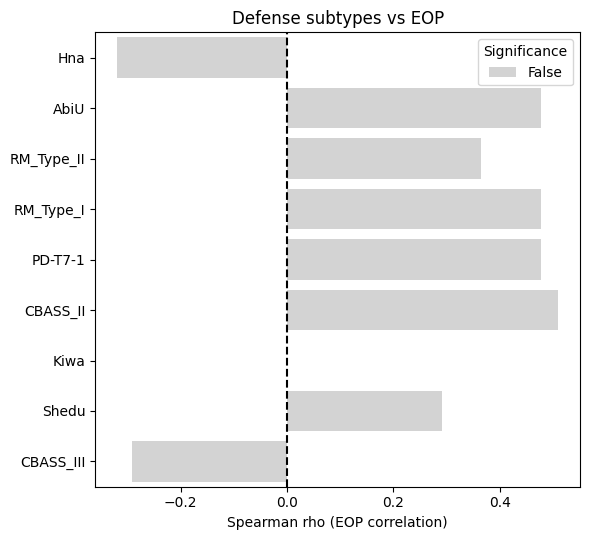

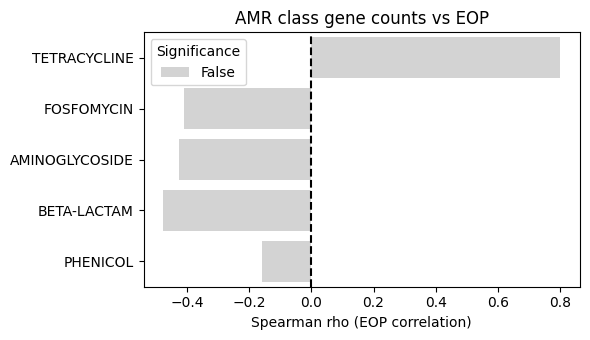

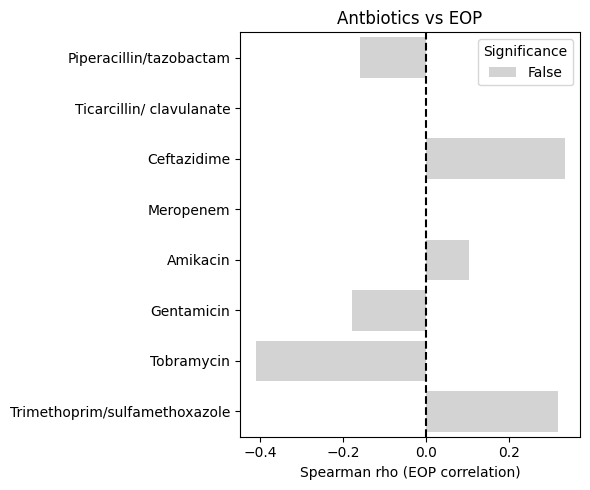

In [ ]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

def plot_correlations(df, feature_col, rho_col, p_col, title):
    df = df.copy()
    df["Significance"] = df[p_col] < 0.05
    plt.figure(figsize=(6, len(df)*0.5 + 1))
    sns.barplot(data=df, x=rho_col, y=feature_col, hue="Significance",
                palette={True: "crimson", False: "lightgrey"}, dodge=False)
    plt.axvline(0, color="black", linestyle="--")
    plt.title(title)
    plt.xlabel("Spearman rho (EOP correlation)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


plot_correlations(defense_corr_df_corr, "defense_subtype", "rho", "p_adj",
                  "Defense subtypes vs EOP")

plot_correlations(corr_df_corr, "AMR_class", "rho", "p_adj",
                  "AMR class gene counts vs EOP")

plot_correlations(corr_df_corr2, "antibiotic", "rho", "p_adj",
                  "Antbiotics vs EOP")

### Tail proteins to EOP

### Correlating EOP to Receptor binding proteins and other phage tail proteins

RBP were detected using PhageRBPDetect, https://github.com/dimiboeckaerts/PhageRBPdetection




In [ ]:
# Example usage:  Replace with your desired gene IDs, from predicred PhageRBPDetect
qgeneID_subset = ["JDOEVDKM_CDS_0024", "JDOEVDKM_CDS_0028", "JDOEVDKM_CDS_0029", "AXUUMYTS_CDS_0021", "AXUUMYTS_CDS_0018", "IFXVGPNG_CDS_0028", "IFXVGPNG_CDS_0032", "IFXVGPNG_CDS_0027", "IHDRJJQR_CDS_0029", "IHDRJJQR_CDS_0034", "MPKKVJWZ_CDS_0014", "JJIYCMYV_CDS_0023", "OKILJAZK_CDS_0015", "OKILJAZK_CDS_0012", "BUBCVPIM_CDS_0027", "QLZSKYRQ_CDS_0032", "QLZSKYRQ_CDS_0029", "MOJOLAXZ_CDS_0031", "MOJOLAXZ_CDS_0024", "VCKTMGAM_CDS_0031", "VCKTMGAM_CDS_0029", "LDQZVDBU_CDS_0031", "YRFTTTDG_CDS_0017", "YRFTTTDG_CDS_0020", "VNLSRWGA_CDS_0023", "VNLSRWGA_CDS_0027", "JZFESBBW_CDS_0024"]
rgeneID_subset = ["JDOEVDKM_CDS_0024", "JDOEVDKM_CDS_0028", "JDOEVDKM_CDS_0029", "AXUUMYTS_CDS_0021", "AXUUMYTS_CDS_0018", "IFXVGPNG_CDS_0028", "IFXVGPNG_CDS_0032", "IFXVGPNG_CDS_0027", "IHDRJJQR_CDS_0029", "IHDRJJQR_CDS_0034", "MPKKVJWZ_CDS_0014", "JJIYCMYV_CDS_0023", "OKILJAZK_CDS_0015", "OKILJAZK_CDS_0012", "BUBCVPIM_CDS_0027", "QLZSKYRQ_CDS_0032", "QLZSKYRQ_CDS_0029", "MOJOLAXZ_CDS_0031", "MOJOLAXZ_CDS_0024", "VCKTMGAM_CDS_0031", "VCKTMGAM_CDS_0029", "LDQZVDBU_CDS_0031", "YRFTTTDG_CDS_0017", "YRFTTTDG_CDS_0020", "VNLSRWGA_CDS_0023", "VNLSRWGA_CDS_0027", "JZFESBBW_CDS_0024"]
# Regex pattern for tail-related genes
tail_pattern = r"(tail|fiber|spike|sheath|baseplate|rbp|receptor)"

In [ ]:
gene_matrix =pd.read_csv("Phage_gene_matrix.csv")
gene_matrix

,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,qproduct,qgeneID,rproduct,rgeneID,merged_query,merged_query_name,merged_ref,merged_ref_name
0,ewik,Ewik_contig_1,0,1134,coliflower,Coliflower_contig_1,565,1129,100.0,1.140000e-108,terminase large subunit,AXUUMYTS_CDS_0001,terminase large subunit,JDOEVDKM_CDS_0002,ewik - AXUUMYTS_CDS_0001,ewik - AXUUMYTS_CDS_0001 - terminase large sub...,coliflower - JDOEVDKM_CDS_0002,coliflower - JDOEVDKM_CDS_0002 - terminase lar...
1,ewik,Ewik_contig_1,1136,2675,coliflower,Coliflower_contig_1,1483,2524,99.1,1.130000e-231,portal protein,AXUUMYTS_CDS_0002,portal protein,JDOEVDKM_CDS_0004,ewik - AXUUMYTS_CDS_0002,ewik - AXUUMYTS_CDS_0002 - portal protein,coliflower - JDOEVDKM_CDS_0004,coliflower - JDOEVDKM_CDS_0004 - portal protein
2,ewik,Ewik_contig_1,6569,7490,coliflower,Coliflower_contig_1,6915,8250,98.2,8.050000e-186,minor tail protein,AXUUMYTS_CDS_0005,minor tail protein,JDOEVDKM_CDS_0016,ewik - AXUUMYTS_CDS_0005,ewik - AXUUMYTS_CDS_0005 - minor tail protein,coliflower - JDOEVDKM_CDS_0016,coliflower - JDOEVDKM_CDS_0016 - minor tail pr...
3,ewik,Ewik_contig_1,8062,8494,coliflower,Coliflower_contig_1,8281,8647,97.1,5.070000e-68,Tail assembly chaperone,AXUUMYTS_CDS_0007,Tail assembly chaperone,JDOEVDKM_CDS_0017,ewik - AXUUMYTS_CDS_0007,ewik - AXUUMYTS_CDS_0007 - Tail assembly chape...,coliflower - JDOEVDKM_CDS_0017,coliflower - JDOEVDKM_CDS_0017 - Tail assembly...
4,ewik,Ewik_contig_1,9743,9293,coliflower,Coliflower_contig_1,9050,9500,99.3,1.200000e-94,tail length tape measure protein,AXUUMYTS_CDS_0008,tail completion or Neck1 protein,JDOEVDKM_CDS_0020,ewik - AXUUMYTS_CDS_0008,ewik - AXUUMYTS_CDS_0008 - tail length tape me...,coliflower - JDOEVDKM_CDS_0020,coliflower - JDOEVDKM_CDS_0020 - tail completi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8629,shaaii,Tuull_contig_1,30540,30756,nyashin,Nyashin_contig_1,31128,31356,80.0,2.190000e-42,transcriptional repressor,YRFTTTDG_CDS_0033,transcriptional repressor,BUBCVPIM_CDS_0047,shaaii - YRFTTTDG_CDS_0033,shaaii - YRFTTTDG_CDS_0033 - transcriptional r...,nyashin - BUBCVPIM_CDS_0047,nyashin - BUBCVPIM_CDS_0047 - transcriptional ...
8630,shaaii,Tuull_contig_1,33967,34723,nyashin,Nyashin_contig_1,34562,35288,65.6,1.050000e-103,hypothetical protein,YRFTTTDG_CDS_0037,hypothetical protein,BUBCVPIM_CDS_0052,shaaii - YRFTTTDG_CDS_0037,shaaii - YRFTTTDG_CDS_0037 - hypothetical protein,nyashin - BUBCVPIM_CDS_0052,nyashin - BUBCVPIM_CDS_0052 - hypothetical pro...
8631,shaaii,Tuull_contig_1,36059,36368,nyashin,Nyashin_contig_1,36699,37008,99.0,7.210000e-69,hypothetical protein,YRFTTTDG_CDS_0043,hypothetical protein,BUBCVPIM_CDS_0057,shaaii - YRFTTTDG_CDS_0043,shaaii - YRFTTTDG_CDS_0043 - hypothetical protein,nyashin - BUBCVPIM_CDS_0057,nyashin - BUBCVPIM_CDS_0057 - hypothetical pro...
8632,shaaii,Tuull_contig_1,37196,37886,nyashin,Nyashin_contig_1,38068,38608,82.6,6.230000e-99,hypothetical protein,YRFTTTDG_CDS_0045,hypothetical protein,BUBCVPIM_CDS_0061,shaaii - YRFTTTDG_CDS_0045,shaaii - YRFTTTDG_CDS_0045 - hypothetical protein,nyashin - BUBCVPIM_CDS_0061,nyashin - BUBCVPIM_CDS_0061 - hypothetical pro...


In [ ]:
# If you want rsubset to be identical (as in your message)
rgeneID_subset = qgeneID_subset.copy()

# Pick which one you want to use:
selected_ids = qgeneID_subset  # or rgeneID_subset


# ---- Filtering ----

# 1. Match tail-annotated genes
tail_hits = gene_matrix[gene_matrix["qgeneID"].str.contains(tail_pattern, case=False, regex=True)]

# 2. Match curated list of gene IDs
list_hits = gene_matrix[gene_matrix["rgeneID"].isin(selected_ids)]

# 3. Combine (union) both sets
combined_subset = pd.concat([tail_hits, list_hits]).drop_duplicates()
combined_subset

/tmp/ipykernel_5503/99430094.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  tail_hits = gene_matrix[gene_matrix["qgeneID"].str.contains(tail_pattern, case=False, regex=True)]


,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,qproduct,qgeneID,rproduct,rgeneID,merged_query,merged_query_name,merged_ref,merged_ref_name
9,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,tail fiber protein,AXUUMYTS_CDS_0018,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...
11,ewik,Ewik_contig_1,18329,21614,coliflower,Coliflower_contig_1,16756,19069,95.3,7.311000e-316,central tail fiber J,AXUUMYTS_CDS_0021,central tail fiber J,JDOEVDKM_CDS_0028,ewik - AXUUMYTS_CDS_0021,ewik - AXUUMYTS_CDS_0021 - central tail fiber J,coliflower - JDOEVDKM_CDS_0028,coliflower - JDOEVDKM_CDS_0028 - central tail ...
67,ewik,Ewik_contig_1,17358,15213,gadget,Gadget_contig_1,13643,14699,47.7,6.250000e-87,tail fiber protein,AXUUMYTS_CDS_0018,virion structural protein,IFXVGPNG_CDS_0027,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,gadget - IFXVGPNG_CDS_0027,gadget - IFXVGPNG_CDS_0027 - virion structural...
68,ewik,Ewik_contig_1,18329,21614,gadget,Gadget_contig_1,17003,20501,94.9,0.000000e+00,central tail fiber J,AXUUMYTS_CDS_0021,central tail fiber J,IFXVGPNG_CDS_0032,ewik - AXUUMYTS_CDS_0021,ewik - AXUUMYTS_CDS_0021 - central tail fiber J,gadget - IFXVGPNG_CDS_0032,gadget - IFXVGPNG_CDS_0032 - central tail fiber J
107,ewik,Ewik_contig_1,18329,21614,infector,Infector_contig_1,16891,20389,100.0,0.000000e+00,central tail fiber J,AXUUMYTS_CDS_0021,central tail fiber J,IHDRJJQR_CDS_0034,ewik - AXUUMYTS_CDS_0021,ewik - AXUUMYTS_CDS_0021 - central tail fiber J,infector - IHDRJJQR_CDS_0034,infector - IHDRJJQR_CDS_0034 - central tail fi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8490,shaaii,Tuull_contig_1,17813,21809,kuwaak,Kuwaak_contig_1,15752,19250,43.9,5.310000e-297,central tail fiber J,YRFTTTDG_CDS_0020,central tail fiber J,MPKKVJWZ_CDS_0014,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,kuwaak - MPKKVJWZ_CDS_0014,kuwaak - MPKKVJWZ_CDS_0014 - central tail fiber J
8502,shaaii,Tuull_contig_1,15724,16849,maay,Maay_contig_1,13397,15668,31.4,8.000000e-07,tail fiber assembly,YRFTTTDG_CDS_0017,virion structural protein,OKILJAZK_CDS_0012,shaaii - YRFTTTDG_CDS_0017,shaaii - YRFTTTDG_CDS_0017 - tail fiber assembly,maay - OKILJAZK_CDS_0012,maay - OKILJAZK_CDS_0012 - virion structural p...
8508,shaaii,Tuull_contig_1,17813,21809,maay,Maay_contig_1,16603,20101,43.9,2.420000e-297,central tail fiber J,YRFTTTDG_CDS_0020,central tail fiber J,OKILJAZK_CDS_0015,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,maay - OKILJAZK_CDS_0015,maay - OKILJAZK_CDS_0015 - central tail fiber J
8517,shaaii,Tuull_contig_1,17813,21809,saurus,Saurus_contig_1,16496,19598,39.9,2.170000e-238,central tail fiber J,YRFTTTDG_CDS_0020,central tail fiber J,VCKTMGAM_CDS_0029,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,saurus - VCKTMGAM_CDS_0029,saurus - VCKTMGAM_CDS_0029 - central tail fiber J


In [ ]:
eop_values = pd.read_csv("EOP_values.csv")
eop_values['EOP'] = eop_values['EOP'].str.lower()

# Melt directly from the original eop_values DataFrame
eop_long = eop_values.melt(
    id_vars=["EOP"], # Use the existing 'EOP' column as the identifier
    var_name="bacteria",
    value_name="EOP_value"
).rename(columns={"EOP": "phage"}) # Rename 'EOP' to 'phage' after melting

combined_subset = pd.concat([tail_hits, list_hits]).drop_duplicates()
merged_subset_eop = combined_subset.merge(eop_long, left_on="queryID", right_on="phage", how="left")
merged_subset_eop

,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,...,qgeneID,rproduct,rgeneID,merged_query,merged_query_name,merged_ref,merged_ref_name,phage,bacteria,EOP_value
0,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,AXUUMYTS_CDS_0018,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans jini,0
1,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,AXUUMYTS_CDS_0018,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans ayb,1
2,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,AXUUMYTS_CDS_0018,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans suz,1
3,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,AXUUMYTS_CDS_0018,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus vya,1
4,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,AXUUMYTS_CDS_0018,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus neet,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,YRFTTTDG_CDS_0020,central tail fiber J,LDQZVDBU_CDS_0031,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A xylosoxidans suz,1
2180,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,YRFTTTDG_CDS_0020,central tail fiber J,LDQZVDBU_CDS_0031,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A insolitus vya,1
2181,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,YRFTTTDG_CDS_0020,central tail fiber J,LDQZVDBU_CDS_0031,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A insolitus neet,1
2182,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,YRFTTTDG_CDS_0020,central tail fiber J,LDQZVDBU_CDS_0031,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A insolitus aura,0


Code to cluster these genes using networkx

In [ ]:
import networkx as nx
import pandas as pd

# Filter pairwise similarities (from your similarity file)
df = merged_subset_eop   # e.g. the phynteny or pharokka BLAST output

# Only keep strong links (e.g. ≥90% identity)
df_high = df[df["identity"] >= 90]

# Build graph
G = nx.Graph()
G.add_edges_from(df_high[["qgeneID", "rgeneID"]].itertuples(index=False, name=None))
clusters = []
for i, comp in enumerate(nx.connected_components(G), start=1):
    for gene in comp:
        clusters.append({"gene": gene, "cluster": f"cluster_{i}"})

clusters_df = pd.DataFrame(clusters)

# very important to note I AM MERGING ONLY ON QGENEID
combined_with_clusters = merged_subset_eop.merge(
    clusters_df,
    left_on="qgeneID",     # or "qgeneID"
    right_on="gene",
    how="left"
)
combined_with_clusters

,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,...,rgeneID,merged_query,merged_query_name,merged_ref,merged_ref_name,phage,bacteria,EOP_value,gene,cluster
0,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans jini,0,AXUUMYTS_CDS_0018,cluster_2
1,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans ayb,1,AXUUMYTS_CDS_0018,cluster_2
2,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans suz,1,AXUUMYTS_CDS_0018,cluster_2
3,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus vya,1,AXUUMYTS_CDS_0018,cluster_2
4,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus neet,1,AXUUMYTS_CDS_0018,cluster_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,LDQZVDBU_CDS_0031,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A xylosoxidans suz,1,YRFTTTDG_CDS_0020,cluster_8
2180,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,LDQZVDBU_CDS_0031,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A insolitus vya,1,YRFTTTDG_CDS_0020,cluster_8
2181,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,LDQZVDBU_CDS_0031,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A insolitus neet,1,YRFTTTDG_CDS_0020,cluster_8
2182,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,LDQZVDBU_CDS_0031,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A insolitus aura,0,YRFTTTDG_CDS_0020,cluster_8


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# ----------------------------
# 1️⃣ Build per-phage cluster counts (or presence)
# ----------------------------

# Each row in combined_with_clusters is a gene with a cluster label and phage ID
# Collapse to phage × cluster table
cluster_counts = (
    combined_with_clusters
    .dropna(subset=["cluster"])  # just in case
    .groupby(["phage", "cluster"])
    .size()
    .reset_index(name="count")
)

# Pivot to wide: one row per phage, one column per cluster
cluster_matrix = (
    cluster_counts
    .pivot(index="phage", columns="cluster", values="count")
    .fillna(0)
    .reset_index()
)

# OPTIONAL: make it presence/absence instead of counts
# cluster_matrix.loc[:, cluster_matrix.columns != "phage"] = (
#     cluster_matrix.loc[:, cluster_matrix.columns != "phage"] > 0
# ).astype(int)

# ----------------------------
# 2️⃣ Merge with EOP data
# ----------------------------

# eop_long: phage × bacteria × EOP_value
# Merge cluster_matrix on phage
merged = eop_long.merge(cluster_matrix, on="phage", how="left").fillna(0)

# ----------------------------
# 3️⃣ Compute Spearman correlations: EOP vs each cluster
# ----------------------------

correlation_results = []

cluster_cols = [c for c in cluster_matrix.columns if c != "phage"]

for cluster_col in cluster_cols:
    # Make sure there is variation in both variables
    if merged[cluster_col].nunique() > 1 and merged["EOP_value"].nunique() > 1:
        rho, p_value = spearmanr(
            merged["EOP_value"],
            merged[cluster_col],
            nan_policy="omit"
        )
        correlation_results.append({
            "cluster": cluster_col,
            "spearman_rho": rho,
            "p_value": p_value
        })

corr_df = pd.DataFrame(correlation_results)

# ----------------------------
# 4️⃣ Benjamini–Hochberg FDR correction
# ----------------------------

if not corr_df.empty:
    reject, p_adj, _, _ = multipletests(corr_df["p_value"], method="fdr_bh")
    corr_df["p_adj"] = p_adj
    corr_df["significant"] = reject  # True/False at alpha=0.05
    corr_df = corr_df.sort_values("p_adj")
else:
    corr_df["p_adj"] = []
    corr_df["significant"] = []

cluster_corr_df = corr_df

print("Spearman correlations: EOP vs cluster presence/count")
display(cluster_corr_df)


Spearman correlations: EOP vs cluster presence/count


,cluster,spearman_rho,p_value,p_adj,significant
1,cluster_2,0.355748,0.000196,0.001567,True
0,cluster_1,0.322817,0.000783,0.003133,True
6,cluster_7,-0.227879,0.019389,0.038779,True
4,cluster_5,-0.227879,0.019389,0.038779,True
5,cluster_6,-0.193455,0.048006,0.076810,False
3,cluster_4,-0.163952,0.094678,0.126237,False
7,cluster_8,-0.154706,0.115075,0.131514,False
2,cluster_3,0.011333,0.908648,0.908648,False


In [ ]:
cluster_to_genesID = (
    combined_with_clusters
    .groupby("cluster")["qgeneID"]
    .apply(lambda x: sorted(x.dropna().unique()))
    .to_dict()
)

cluster_to_genesID

{'cluster_1': ['AXUUMYTS_CDS_0021',
  'IFXVGPNG_CDS_0032',
  'IHDRJJQR_CDS_0034',
  'JDOEVDKM_CDS_0028',
  'JDOEVDKM_CDS_0029',
  'JZFESBBW_CDS_0030',
  'JZFESBBW_CDS_0032',
  'MOJOLAXZ_CDS_0030',
  'MOJOLAXZ_CDS_0031',
  'MPKKVJWZ_CDS_0014',
  'OKILJAZK_CDS_0015',
  'QLZSKYRQ_CDS_0032',
  'VNLSRWGA_CDS_0027',
  'VNLSRWGA_CDS_0028'],
 'cluster_2': ['AXUUMYTS_CDS_0018',
  'IHDRJJQR_CDS_0029',
  'JDOEVDKM_CDS_0024',
  'JZFESBBW_CDS_0026',
  'MOJOLAXZ_CDS_0024',
  'QLZSKYRQ_CDS_0029',
  'VNLSRWGA_CDS_0023'],
 'cluster_3': ['IHDRJJQR_CDS_0028',
  'JZFESBBW_CDS_0024',
  'MOJOLAXZ_CDS_0023',
  'QLZSKYRQ_CDS_0027'],
 'cluster_4': ['MPKKVJWZ_CDS_0012', 'OKILJAZK_CDS_0012'],
 'cluster_5': ['LDQZVDBU_CDS_0031', 'VCKTMGAM_CDS_0029'],
 'cluster_6': ['LDQZVDBU_CDS_0033'],
 'cluster_7': ['BUBCVPIM_CDS_0027', 'JJIYCMYV_CDS_0023'],
 'cluster_8': ['BUBCVPIM_CDS_0028', 'JJIYCMYV_CDS_0024', 'YRFTTTDG_CDS_0020']}

In [ ]:
cluster_to_genes = (
    combined_with_clusters
    .groupby("cluster")["qproduct"]
    .apply(lambda x: sorted(x.dropna().unique()))
    .to_dict()
)

cluster_to_genes

{'cluster_1': ['central tail fiber J', 'tail fiber protein'],
 'cluster_2': ['hypothetical protein',
  'tail fiber protein',
  'virion structural protein'],
 'cluster_3': ['hypothetical protein', 'tail fiber protein'],
 'cluster_4': ['virion structural protein'],
 'cluster_5': ['central tail fiber J'],
 'cluster_6': ['membrane associated protein'],
 'cluster_7': ['central tail fiber J'],
 'cluster_8': ['central tail fiber J']}

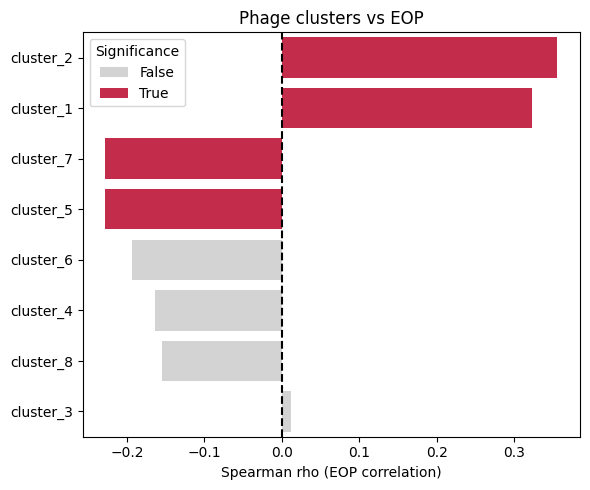

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

def plot_correlations(df, feature_col, rho_col, p_col, title, do_fdr=True):

    df = df.copy()

    # ----------------------------
    # FDR correction (Benjamini–Hochberg)
    # ----------------------------
    if do_fdr:
        reject, p_adj, _, _ = multipletests(df[p_col], method="fdr_bh")
        df["p_adj"] = p_adj
        df["Significance"] = p_adj < 0.05
        p_use = "p_adj"
    else:
        df["Significance"] = df[p_col] < 0.05
        p_use = p_col

    # ----------------------------
    # Plot
    # ----------------------------
    plt.figure(figsize=(6, len(df)*0.5 + 1))

    sns.barplot(
        data=df,
        x=rho_col,
        y=feature_col,
        hue="Significance",
        palette={True: "crimson", False: "lightgrey"},
        dodge=False
    )

    plt.axvline(0, color="black", linestyle="--")
    plt.title(title)
    plt.xlabel("Spearman rho (EOP correlation)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

cluster_corr_df = plot_correlations(
    cluster_corr_df,
    "cluster",
    "spearman_rho",
    "p_value",   # raw p-values go in
    "Phage clusters vs EOP"
)

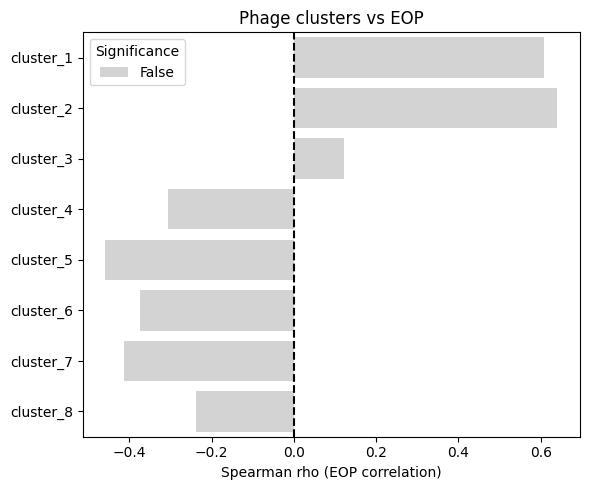

In [ ]:
import numpy as np

# Ensure 'log_EOP' exists in combined_with_clusters
if 'log_EOP' not in combined_with_clusters.columns:
    combined_with_clusters['log_EOP'] = np.log10(combined_with_clusters['EOP_value'] + 1e-9)

phage_eop = (
    combined_with_clusters # Changed from interaction_df to combined_with_clusters
    .groupby("phage", as_index=False) # Changed from phage_id to phage
    .agg(
        mean_log_EOP=("log_EOP", "mean")
    )
)

# Define phage_features_df and phage_features based on cluster_matrix
# cluster_matrix has 'phage' column, which should be the index for features_df
phage_features_df = cluster_matrix.set_index('phage')
phage_features = [col for col in phage_features_df.columns if col.startswith('cluster_')]

from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests # Import for FDR correction

results = []

# Set 'phage' as index for phage_eop for easier alignment
phage_eop_indexed = phage_eop.set_index('phage')

# Merge to get a single DataFrame for correlation
merged_for_corr = phage_eop_indexed.merge(
    phage_features_df,
    left_index=True,
    right_index=True,
    how='inner' # Only phages present in both
)

for feature in phage_features:
    eop_series = merged_for_corr["mean_log_EOP"]
    feature_series = merged_for_corr[feature]

    if feature_series.nunique() > 1 and eop_series.nunique() > 1:
        rho, p = spearmanr(
            eop_series,
            feature_series,
            nan_policy='omit' # handle NaNs if any are still present
        )

        results.append({
            "feature": feature,
            "spearman_rho": rho,
            "p_value": p
        })
    else:
        results.append({
            "feature": feature,
            "spearman_rho": np.nan,
            "p_value": np.nan
        })

cluster_corr_df_corr = pd.DataFrame(results)

# --- Apply Benjamini–Hochberg FDR correction ---
if not cluster_corr_df_corr.empty and 'p_value' in cluster_corr_df_corr.columns:
    reject, p_adj, _, _ = multipletests(cluster_corr_df_corr['p_value'].dropna(), method='fdr_bh')
    # Map p_adj back to the original DataFrame, handling NaNs
    original_indices = cluster_corr_df_corr['p_value'].dropna().index
    p_adj_series = pd.Series(p_adj, index=original_indices)
    cluster_corr_df_corr['p_adj'] = cluster_corr_df_corr['p_value'].map(p_adj_series)
    cluster_corr_df_corr['significant'] = reject
else:
    cluster_corr_df_corr['p_adj'] = np.nan
    cluster_corr_df_corr['significant'] = False

plot_correlations(
    cluster_corr_df_corr,
    "feature", # Changed 'cluster' to 'feature' to match the column name in cluster_corr_df_corr
    "spearman_rho",
    "p_adj",
    "Phage clusters vs EOP"
)


In [ ]:
cluster_corr_df_corr

,feature,spearman_rho,p_value,p_adj,significant
0,cluster_1,0.608251,0.016134,NaN,False
1,cluster_2,0.640510,0.010098,NaN,False
2,cluster_3,0.122742,0.662987,NaN,False
3,cluster_4,-0.304572,0.269699,NaN,False
4,cluster_5,-0.458029,0.085992,NaN,False
5,cluster_6,-0.374513,0.169031,NaN,False
6,cluster_7,-0.412226,0.126791,NaN,False
7,cluster_8,-0.237424,0.394187,NaN,False


In [ ]:
combined_with_clusters.to_csv("combined_with_clusters.tsv", sep="\t", index=False)


### Tail clusters distribution plots

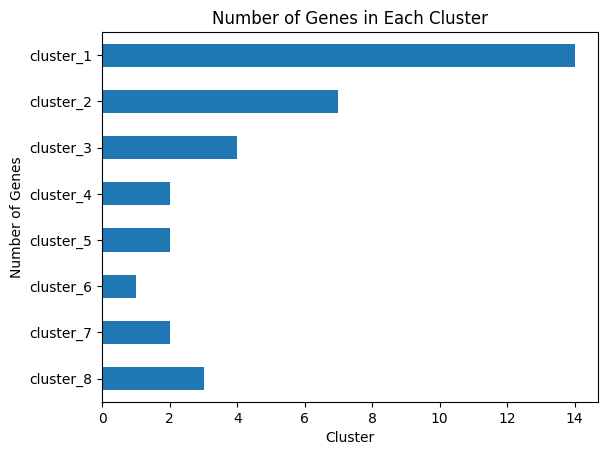

In [ ]:
#plot bar graph with number of genes in each cluster
#order = ["cluster_3", "cluster_8", "cluster_4", "cluster_6", "cluster_5","cluster_7","cluster_1", "cluster_2"]
order = ["cluster_8", "cluster_7", "cluster_6", "cluster_5", "cluster_4", "cluster_3", "cluster_2", "cluster_1"]
counts = (
    combined_with_clusters
    .groupby("cluster")["gene"]   # or "Protein id", etc.
    .nunique()
)

counts = counts.reindex(order)  # reorders to your order

counts.plot(kind='barh')
plt.xlabel('Cluster')
plt.ylabel('Number of Genes')
plt.title('Number of Genes in Each Cluster')
plt.show()

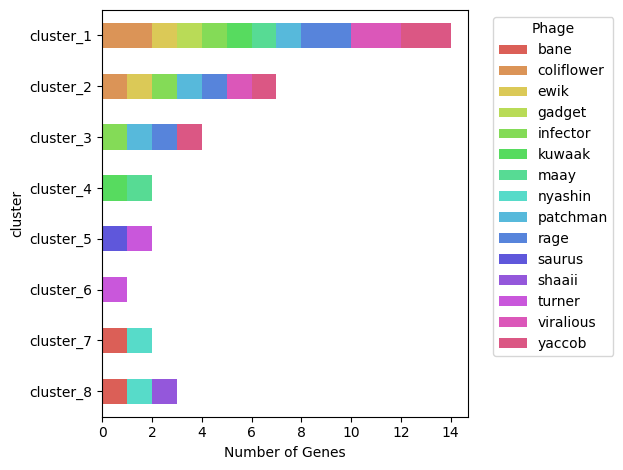

In [ ]:
# function to count unique genes per group
def unique_genes(df):
    return df['gene'].nunique()  # or df['Protein id'].nunique()

stack_counts = (
    combined_with_clusters
    .groupby(["cluster", "phage"])
    .apply(unique_genes, include_groups=False)
    .reset_index(name="gene_count")
)

stack_wide = (
    stack_counts
    .pivot(index="cluster", columns="phage", values="gene_count")
    .fillna(0)
)

stack_wide = stack_wide.reindex(order)  # reorder clusters like in your first plot

stack_wide.plot(
    kind="barh",
    stacked=True,
    color=sns.color_palette("hls", 15)
)

plt.xlabel("Number of Genes")
plt.legend(title="Phage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

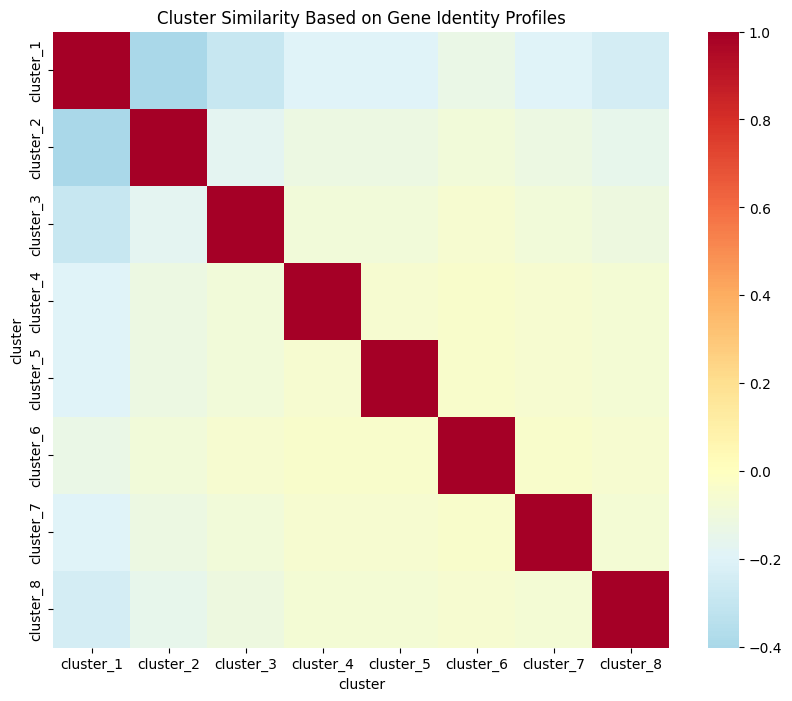

In [ ]:
cluster_gene = (
    combined_with_clusters
    .pivot_table(
        index="cluster",
        columns="gene",
        values="identity",
        aggfunc="mean",
        fill_value=0
    )
)

similarity = cluster_gene.T.corr(method="pearson")

plt.figure(figsize=(10,8))

sns.heatmap(
    similarity,
    cmap="RdYlBu_r",
    center=0,
    square=True
)

plt.title("Cluster Similarity Based on Gene Identity Profiles")
plt.show()

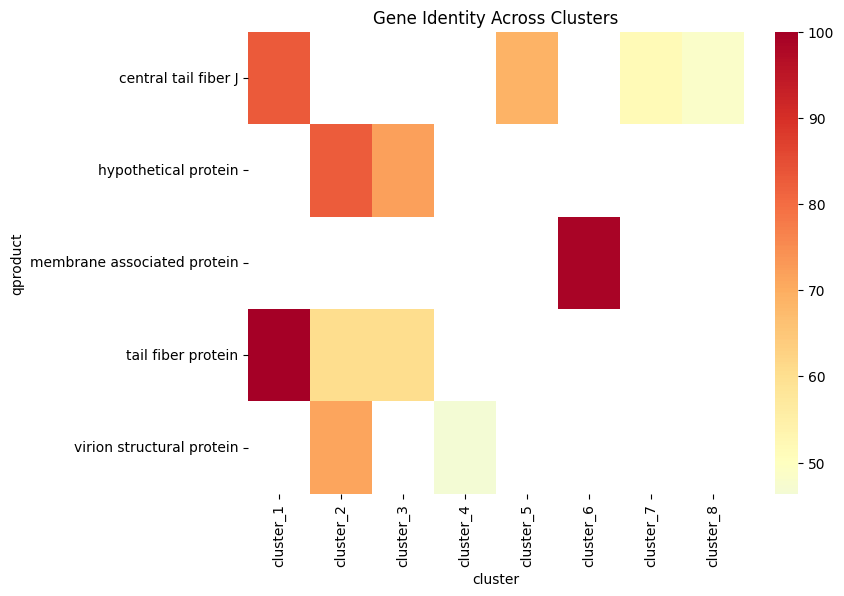

In [ ]:
gene_cluster = (
    combined_with_clusters
    .pivot_table(
        index="qproduct",
        columns="cluster",
        values="identity",
        aggfunc="mean"
    )
)

plt.figure(figsize=(8,6))

sns.heatmap(
    gene_cluster,
    cmap="RdYlBu_r",
    center=50,
)

plt.title("Gene Identity Across Clusters")
plt.show()

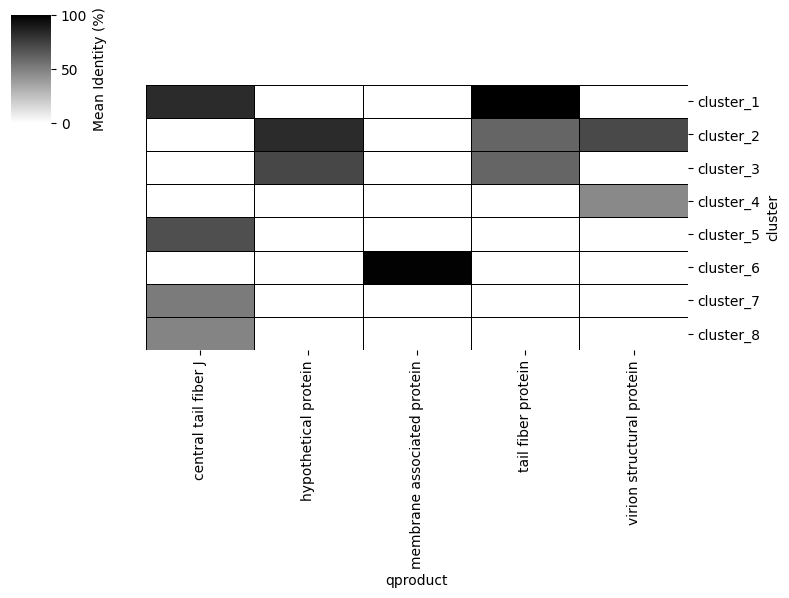

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

gene_cluster = (
    combined_with_clusters
    .pivot_table(
        index="cluster",
        columns="qproduct",
        values="identity",
        aggfunc="mean",
        fill_value=0
    )
)

g = sns.clustermap(
    gene_cluster,
    cmap="binary",
    center=50,
    linewidths=0.5,
    linecolor="black",
    figsize=(8, 6),
    row_cluster=False,
    col_cluster=False,
    cbar_kws={"label": "Mean Identity (%)"}

)

plt.show()

In [ ]:
rbp_genes = set(qgeneID_subset)  # same as rgeneID_subset
rbp_genes

{'AXUUMYTS_CDS_0018',
 'AXUUMYTS_CDS_0021',
 'BUBCVPIM_CDS_0027',
 'IFXVGPNG_CDS_0027',
 'IFXVGPNG_CDS_0028',
 'IFXVGPNG_CDS_0032',
 'IHDRJJQR_CDS_0029',
 'IHDRJJQR_CDS_0034',
 'JDOEVDKM_CDS_0024',
 'JDOEVDKM_CDS_0028',
 'JDOEVDKM_CDS_0029',
 'JJIYCMYV_CDS_0023',
 'JZFESBBW_CDS_0024',
 'LDQZVDBU_CDS_0031',
 'MOJOLAXZ_CDS_0024',
 'MOJOLAXZ_CDS_0031',
 'MPKKVJWZ_CDS_0014',
 'OKILJAZK_CDS_0012',
 'OKILJAZK_CDS_0015',
 'QLZSKYRQ_CDS_0029',
 'QLZSKYRQ_CDS_0032',
 'VCKTMGAM_CDS_0029',
 'VCKTMGAM_CDS_0031',
 'VNLSRWGA_CDS_0023',
 'VNLSRWGA_CDS_0027',
 'YRFTTTDG_CDS_0017',
 'YRFTTTDG_CDS_0020'}

In [ ]:
#checking each cluster
cluster_check = {}

for cluster, genes in cluster_to_genesID.items():
    genes = set(genes)
    missing = genes - rbp_genes

    if len(missing) == 0:
        cluster_check[cluster] = {
            "all_in_rbp_list": True,
            "missing_genes": None
        }
    else:
        cluster_check[cluster] = {
            "all_in_rbp_list": False,
            "missing_genes": sorted(missing)
        }


In [ ]:
for cluster, result in cluster_check.items():
    if result["all_in_rbp_list"]:
        print(f"Cluster {cluster}: TRUE (all genes are predicted RBPs)")
    else:
        print(f"Cluster {cluster}: FALSE")
        print(f"  Missing genes: {', '.join(result['missing_genes'])}")


Cluster cluster_1: FALSE
  Missing genes: JZFESBBW_CDS_0030, JZFESBBW_CDS_0032, MOJOLAXZ_CDS_0030, VNLSRWGA_CDS_0028
Cluster cluster_2: FALSE
  Missing genes: JZFESBBW_CDS_0026
Cluster cluster_3: FALSE
  Missing genes: IHDRJJQR_CDS_0028, MOJOLAXZ_CDS_0023, QLZSKYRQ_CDS_0027
Cluster cluster_4: FALSE
  Missing genes: MPKKVJWZ_CDS_0012
Cluster cluster_5: TRUE (all genes are predicted RBPs)
Cluster cluster_6: FALSE
  Missing genes: LDQZVDBU_CDS_0033
Cluster cluster_7: TRUE (all genes are predicted RBPs)
Cluster cluster_8: FALSE
  Missing genes: BUBCVPIM_CDS_0028, JJIYCMYV_CDS_0024


# Correaltion summary figure

In [ ]:
"""
=============================================================================
SUMMARY FIGURE: ALL SIGNIFICANT CORRELATIONS (Pearson/Spearman)
=============================================================================

Creates a single publication-quality figure showing:
- All significant correlations with EOP
- Color-coded by feature type (defense, AMR genes, phenotype, clusters)
- Effect sizes and p-values
- Grouped for easy interpretation

Install: pip install pandas seaborn matplotlib scipy numpy

=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# FIGURE 1: COMPREHENSIVE FOREST PLOT (ALL SIGNIFICANT CORRELATIONS)
# =============================================================================

def plot_all_significant_correlations(
    defense_corr_df,
    amr_genes_corr_df=None,
    amr_phenotype_corr_df=None,
    tail_cluster_corr_df=None,
    p_threshold=0.05,
    figsize=(14, 12),
    save_path=None
):
    """
    Create comprehensive forest-style plot of all significant correlations.

    Parameters:
    -----------
    defense_corr_df : DataFrame
        Correlations for defense systems with columns: ['defense_subtype', 'rho', 'p_value']
    amr_genes_corr_df : DataFrame
        Correlations for AMR genes
    amr_phenotype_corr_df : DataFrame
        Correlations for AMR phenotypes
    tail_cluster_corr_df : DataFrame
        Correlations for tail clusters
    p_threshold : float
        P-value threshold for significance (default 0.05)
    figsize : tuple
        Figure size
    save_path : str or None
        Path to save figure

    Returns:
    --------
    fig, ax : figure and axes objects
    """

    # Combine all correlations into one dataframe
    all_corr = []

    # Defense systems
    if defense_corr_df is not None and len(defense_corr_df) > 0:
        df = defense_corr_df.copy()
        df['feature_type'] = 'Defense System'
        df['feature'] = df.get('defense_subtype', df.get('feature', 'Unknown'))
        all_corr.append(df)

    # AMR genes
    if amr_genes_corr_df is not None and len(amr_genes_corr_df) > 0:
        df = amr_genes_corr_df.copy()
        df['feature_type'] = 'AMR Gene'
        df['feature'] = df.get('amr_class', df.get('feature', 'Unknown'))
        all_corr.append(df)

    # AMR phenotype
    if amr_phenotype_corr_df is not None and len(amr_phenotype_corr_df) > 0:
        df = amr_phenotype_corr_df.copy()
        df['feature_type'] = 'AMR Phenotype'
        df['feature'] = df.get('phenotype', df.get('feature', 'Unknown'))
        all_corr.append(df)

    # Tail clusters
    if tail_cluster_corr_df is not None and len(tail_cluster_corr_df) > 0:
        df = tail_cluster_corr_df.copy()
        df['feature_type'] = 'Tail Cluster'
        df['feature'] = df.get('cluster', df.get('feature', 'Unknown'))
        all_corr.append(df)

    # Combine
    combined = pd.concat(all_corr, ignore_index=True)

    # Ensure proper column names
    if 'rho' in combined.columns:
        combined['correlation'] = combined['rho']
    elif 'spearman_rho' in combined.columns:
        combined['correlation'] = combined['spearman_rho']
    elif 'pearson_r' in combined.columns:
        combined['correlation'] = combined['pearson_r']
    else:
        # Try to find correlation column
        corr_cols = [c for c in combined.columns if 'rho' in c or 'r' in c]
        if corr_cols:
            combined['correlation'] = combined[corr_cols[0]]

    # Ensure p-value column
    if 'p_value' not in combined.columns:
        if 'p' in combined.columns:
            combined['p_value'] = combined['p']
        elif 'pvalue' in combined.columns:
            combined['p_value'] = combined['pvalue']

    # Filter to significant only
    significant = combined[combined['p_value'] < p_threshold].copy()

    if len(significant) == 0:
        print("No significant correlations found!")
        return None, None

    # Sort by correlation strength
    significant = significant.sort_values('correlation')

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Color map for feature types
    type_colors = {
        'Defense System': '#580F41',      # Blue
        'AMR Gene': '#A9561E',            # Red
        'AMR Phenotype': '#f39c12',       # Orange
        'Tail Cluster': '#029386',        # Green
        'Other': '#95a5a6'                # Gray
    }

    colors = [type_colors.get(ft, '#95a5a6') for ft in significant['feature_type']]

    y_pos = np.arange(len(significant))

    # Plot bars
    bars = ax.barh(y_pos, significant['correlation'],
                   color=colors, edgecolor='black', linewidth=1, alpha=0.8)

    # Add value labels
    for i, (idx, row) in enumerate(significant.iterrows()):
        value = row['correlation']
        p_val = row['p_value']

        # Position label
        x_pos = value + (0.02 if value > 0 else -0.02)
        ha = 'left' if value > 0 else 'right'

        # Format label
        label = f"{value:.3f}\n(p={p_val:.4f})"
        ax.text(x_pos, i, label, va='center', ha=ha, fontsize=8, fontweight='bold')

    # Formatting
    ax.set_yticks(y_pos)
    ax.set_yticklabels(significant['feature'], fontsize=10)
    ax.set_xlabel('Spearman Correlation with log₁₀(EOP)', fontsize=12, fontweight='bold')
    ax.set_title('Significant Associations: All Features vs EOP\n(FDR-corrected p < 0.05)',
                fontsize=14, fontweight='bold', pad=20)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_xlim([significant['correlation'].min() - 0.15,
                 significant['correlation'].max() + 0.15])

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, edgecolor='black', label=ft)
                      for ft, color in type_colors.items() if ft in significant['feature_type'].values]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.95)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {save_path}")

    return fig, ax


# =============================================================================
# FIGURE 2: SUMMARY BY FEATURE TYPE (GROUPED BAR PLOT)
# =============================================================================

def plot_correlations_by_type(
    defense_corr_df=None,
    amr_genes_corr_df=None,
    amr_phenotype_corr_df=None,
    tail_cluster_corr_df=None,
    p_threshold=0.05,
    figsize=(12, 7),
    save_path=None
):
    """
    Create bar plot showing correlation strength by feature type.
    """

    summary_data = []

    # Process each data type
    if defense_corr_df is not None and len(defense_corr_df) > 0:
        df = defense_corr_df.copy()
        sig = df[df['p_value'] < p_threshold]
        summary_data.append({
            'Feature Type': 'Defense Systems',
            'Count': len(sig),
            'Mean Correlation': sig['spearman_rho'].abs().mean() if len(sig) > 0 else 0,
            'Max Correlation': sig['spearman_rho'].abs().max() if len(sig) > 0 else 0
        })

    if amr_genes_corr_df is not None and len(amr_genes_corr_df) > 0:
        df = amr_genes_corr_df.copy()
        sig = df[df['p_value'] < p_threshold]
        summary_data.append({
            'Feature Type': 'AMR Genes',
            'Count': len(sig),
            'Mean Correlation': sig['spearman_rho'].abs().mean() if len(sig) > 0 else 0,
            'Max Correlation': sig['spearman_rho'].abs().max() if len(sig) > 0 else 0
        })

    if amr_phenotype_corr_df is not None and len(amr_phenotype_corr_df) > 0:
        df = amr_phenotype_corr_df.copy()
        sig = df[df['p_value'] < p_threshold]
        summary_data.append({
            'Feature Type': 'AMR Phenotype',
            'Count': len(sig),
            'Mean Correlation': sig['spearman_rho'].abs().mean() if len(sig) > 0 else 0,
            'Max Correlation': sig['spearman_rho'].abs().max() if len(sig) > 0 else 0
        })

    if tail_cluster_corr_df is not None and len(tail_cluster_corr_df) > 0:
        df = tail_cluster_corr_df.copy()
        sig = df[df['p_value'] < p_threshold]
        summary_data.append({
            'Feature Type': 'Tail Clusters',
            'Count': len(sig),
            'Mean Correlation': sig['spearman_rho'].abs().mean() if len(sig) > 0 else 0,
            'Max Correlation': sig['spearman_rho'].abs().max() if len(sig) > 0 else 0
        })

    summary_df = pd.DataFrame(summary_data)

    if len(summary_df) == 0:
        print("No data to plot")
        return None, None

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Plot 1: Number of significant associations
    colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71'][:len(summary_df)]
    bars1 = ax1.bar(summary_df['Feature Type'], summary_df['Count'],
                   color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

    ax1.set_ylabel('Number of Significant Associations', fontsize=11, fontweight='bold')
    ax1.set_title('A. Count of Significant Features', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    # Add count labels
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=10)

    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Plot 2: Mean correlation strength
    bars2 = ax2.bar(summary_df['Feature Type'], summary_df['Mean Correlation'],
                   color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

    ax2.set_ylabel('Mean |Correlation| (Significant Only)', fontsize=11, fontweight='bold')
    ax2.set_title('B. Mean Effect Size', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_ylim([0, 1])

    # Add value labels
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    fig.suptitle('Summary: Significant Correlations with EOP',
                fontsize=13, fontweight='bold', y=1.00)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {save_path}")

    return fig, (ax1, ax2)


# =============================================================================
# FIGURE 3: HEATMAP OF TOP CORRELATIONS
# =============================================================================

def plot_correlation_heatmap(
    all_correlations_df,
    top_n=30,
    figsize=(10, 14),
    save_path=None
):
    """
    Create heatmap of top N correlations.
    """

    # Get top correlations by absolute value
    all_corr = all_correlations_df.copy()

    if 'spearman_rho' in all_corr.columns:
        all_corr['abs_corr'] = all_corr['spearman_rho'].abs()
    elif 'correlation' in all_corr.columns:
        all_corr['abs_corr'] = all_corr['correlation'].abs()

    top_corr = all_corr.nlargest(top_n, 'abs_corr')

    # Create data for heatmap
    heatmap_data = top_corr[['feature', 'spearman_rho']].set_index('feature')
    heatmap_data.columns = ['Correlation with EOP']

    # Create heatmap
    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
               cbar_kws={'label': 'Spearman Correlation'}, ax=ax,
               linewidths=0.5, linecolor='gray')

    ax.set_title(f'Top {top_n} Correlations with log₁₀(EOP)',
                fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {save_path}")

    return fig, ax


# =============================================================================
# HELPER FUNCTION: CALCULATE CORRELATIONS FROM DATA
# =============================================================================

def calculate_correlations_for_features(
    eop_data,
    feature_data,
    feature_name,
    apply_fdr_correction=True
):
    """
    Calculate Spearman correlations between features and EOP.

    Parameters:
    -----------
    eop_data : pd.Series
        EOP values (should be numeric)
    feature_data : pd.DataFrame
        Features to correlate with EOP
    feature_name : str
        Name for the feature type
    apply_fdr_correction : bool
        Apply FDR correction to p-values

    Returns:
    --------
    pd.DataFrame
        Correlation results with columns: [feature, spearman_rho, p_value, p_adj]
    """

    results = []

    for col in feature_data.columns:
        feature_vals = feature_data[col].values

        # Skip if no variation
        if len(np.unique(feature_vals)) <= 1:
            continue

        # Calculate correlation
        rho, p_val = spearmanr(eop_data, feature_vals, nan_policy='omit')

        results.append({
            'feature': col,
            'rho': rho,
            'p': p_val
        })

    corr_df = pd.DataFrame(results)

    # Apply FDR correction
    if apply_fdr_correction and len(corr_df) > 0:
        reject, p_adj, _, _ = multipletests(corr_df['p_value'], method='fdr_bh')
        corr_df['p_adj'] = p_adj
        corr_df['significant'] = reject

    return corr_df


# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":

    print("\n" + "="*80)
    print("SUMMARY FIGURE: ALL SIGNIFICANT CORRELATIONS")
    print("="*80)
    print("\nTo use this script, you need correlation dataframes with columns:")
    print("  - Feature name column (e.g., 'defense_subtype', 'amr_class')")
    print("  - 'spearman_rho' or 'correlation' (correlation coefficient)")
    print("  - 'p_value' (p-value from statistical test)")
    print("\nExample usage:")
    print("""
    # Option 1: From your existing correlation DataFrames
    fig1, ax1 = plot_all_significant_correlations(
        defense_corr_df=defense_corr_df,
        amr_genes_corr_df=amr_genes_corr_df,
        amr_phenotype_corr_df=amr_phenotype_corr_df,
        tail_cluster_corr_df=tail_cluster_corr_df,
        p_threshold=0.05,
        save_path='Fig_All_Correlations.png'
    )

    # Option 2: Summary by type
    fig2, axes2 = plot_correlations_by_type(
        defense_corr_df=defense_corr_df,
        amr_genes_corr_df=amr_genes_corr_df,
        amr_phenotype_corr_df=amr_phenotype_corr_df,
        tail_cluster_corr_df=tail_cluster_corr_df,
        save_path='Fig_Correlations_Summary.png'
    )

    # Option 3: Top correlations heatmap
    fig3, ax3 = plot_correlation_heatmap(
        all_correlations_df=combined_corr,
        top_n=30,
        save_path='Fig_Top_Correlations.png'
    )
    """)

    print("\n" + "="*80)
    print("Available functions:")
    print("="*80)
    print("1. plot_all_significant_correlations() - Main summary figure ⭐")
    print("2. plot_correlations_by_type() - Summary statistics by type")
    print("3. plot_correlation_heatmap() - Heatmap of top correlations")
    print("4. calculate_correlations_for_features() - Calculate correlations from raw data")



SUMMARY FIGURE: ALL SIGNIFICANT CORRELATIONS

To use this script, you need correlation dataframes with columns:
  - Feature name column (e.g., 'defense_subtype', 'amr_class')
  - 'spearman_rho' or 'correlation' (correlation coefficient)
  - 'p_value' (p-value from statistical test)

Example usage:

    # Option 1: From your existing correlation DataFrames
    fig1, ax1 = plot_all_significant_correlations(
        defense_corr_df=defense_corr_df,
        amr_genes_corr_df=amr_genes_corr_df,
        amr_phenotype_corr_df=amr_phenotype_corr_df,
        tail_cluster_corr_df=tail_cluster_corr_df,
        p_threshold=0.05,
        save_path='Fig_All_Correlations.png'
    )

    # Option 2: Summary by type
    fig2, axes2 = plot_correlations_by_type(
        defense_corr_df=defense_corr_df,
        amr_genes_corr_df=amr_genes_corr_df,
        amr_phenotype_corr_df=amr_phenotype_corr_df,
        tail_cluster_corr_df=tail_cluster_corr_df,
        save_path='Fig_Correlations_Summary.png'
    )


Saved: Fig_AllCorrelations.png


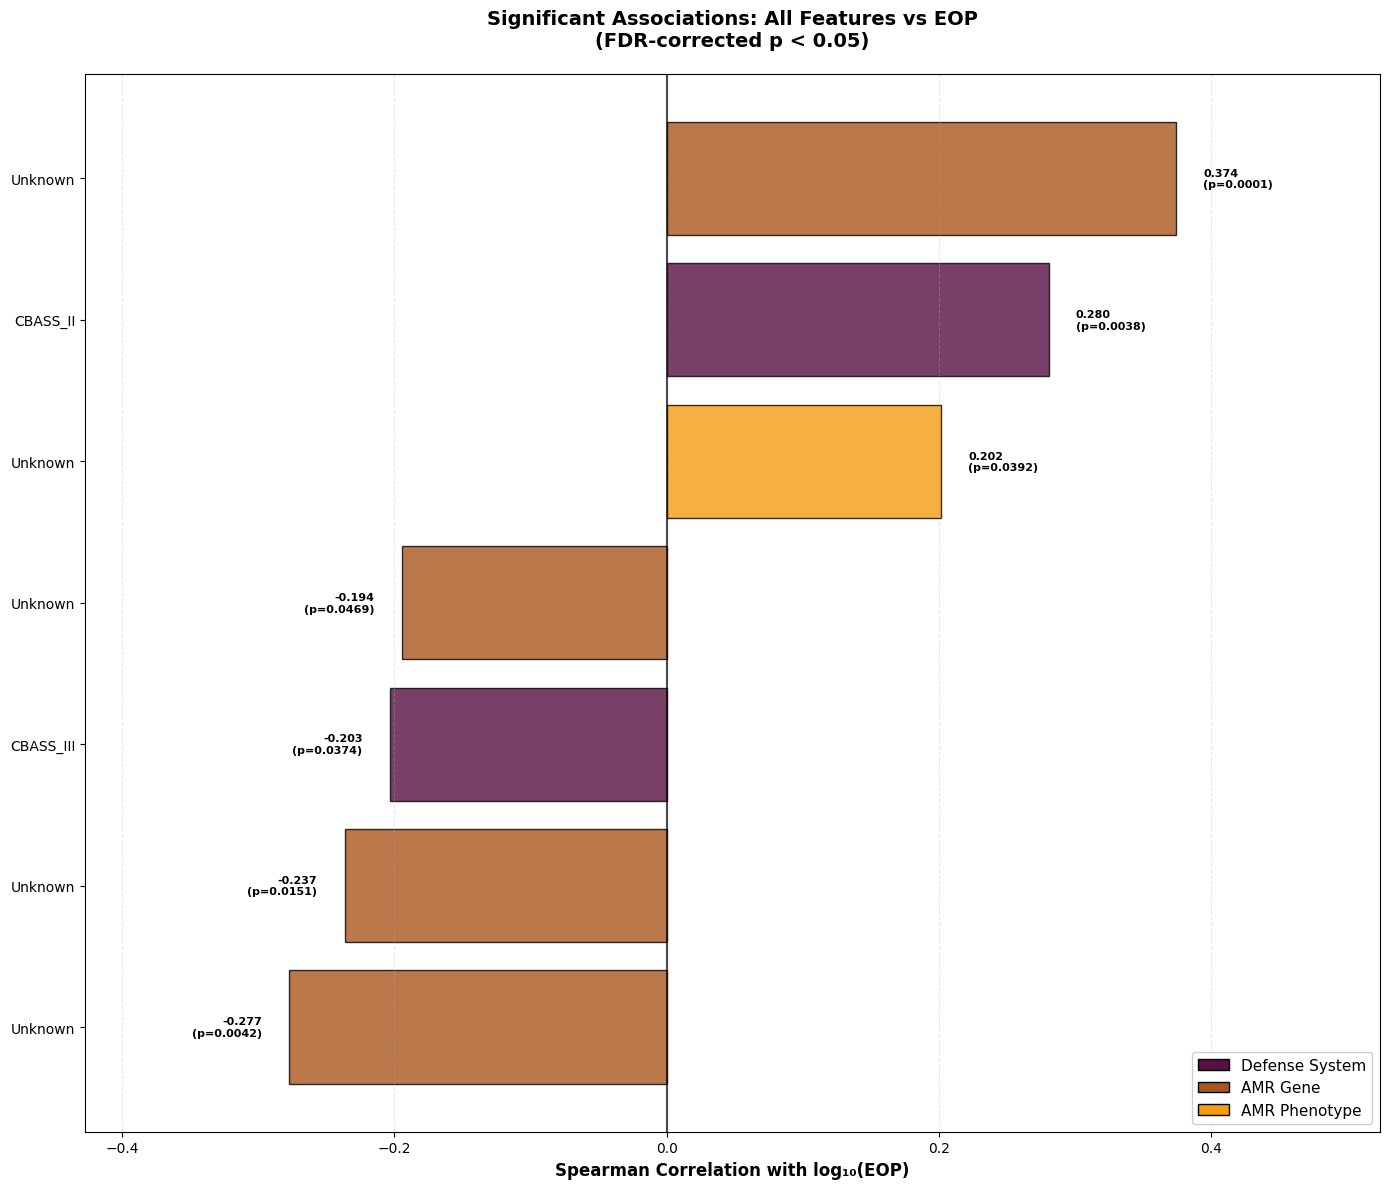

In [ ]:
import matplotlib.pyplot as plt

# Create main figure
fig1, ax1 = plot_all_significant_correlations(
    defense_corr_df=defense_corr_df,
    amr_genes_corr_df=amr_class_corr_df,
    amr_phenotype_corr_df=antibiotic_corr_df,
    tail_cluster_corr_df=cluster_corr_df,
    p_threshold=0.05,
    save_path='Fig_AllCorrelations.png'
)

plt.show()

Saved: Fig_CorrelationsSummary.png


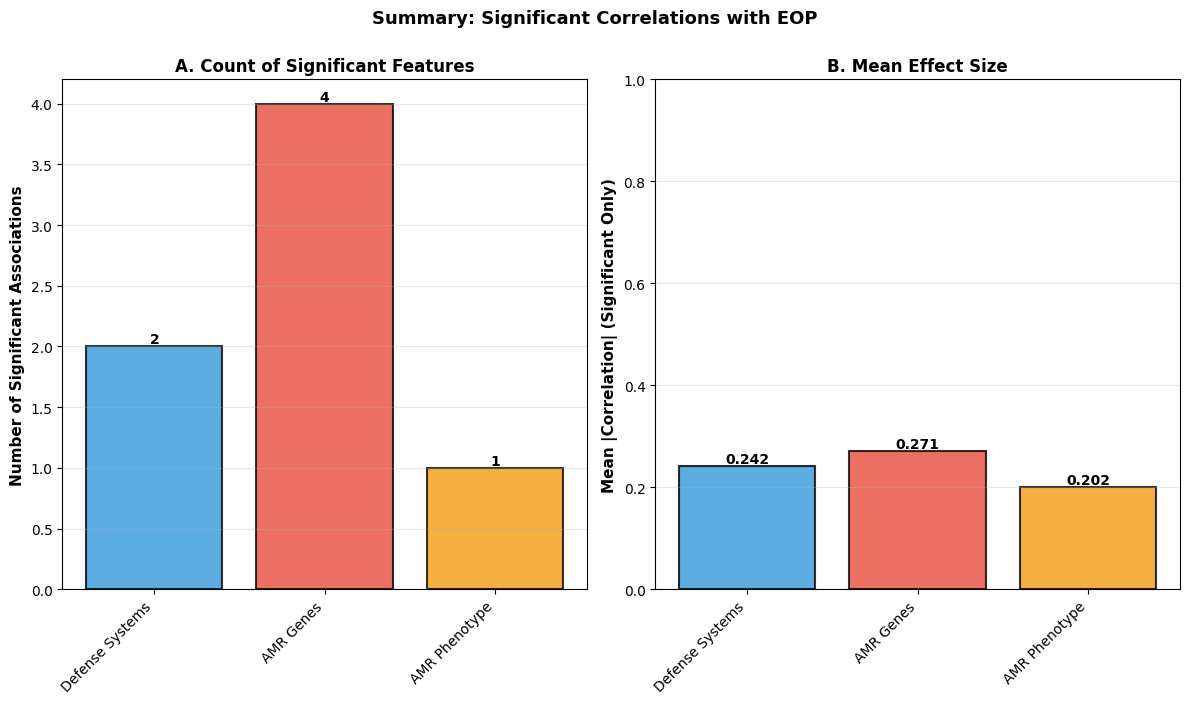

In [ ]:
fig2, (ax1, ax2) = plot_correlations_by_type(
     defense_corr_df=defense_corr_df,
    amr_genes_corr_df=amr_class_corr_df,
    amr_phenotype_corr_df=antibiotic_corr_df,
    tail_cluster_corr_df=cluster_corr_df,
    save_path='Fig_CorrelationsSummary.png'
)

plt.show()

Saved: Fig_AllCorrelations.png


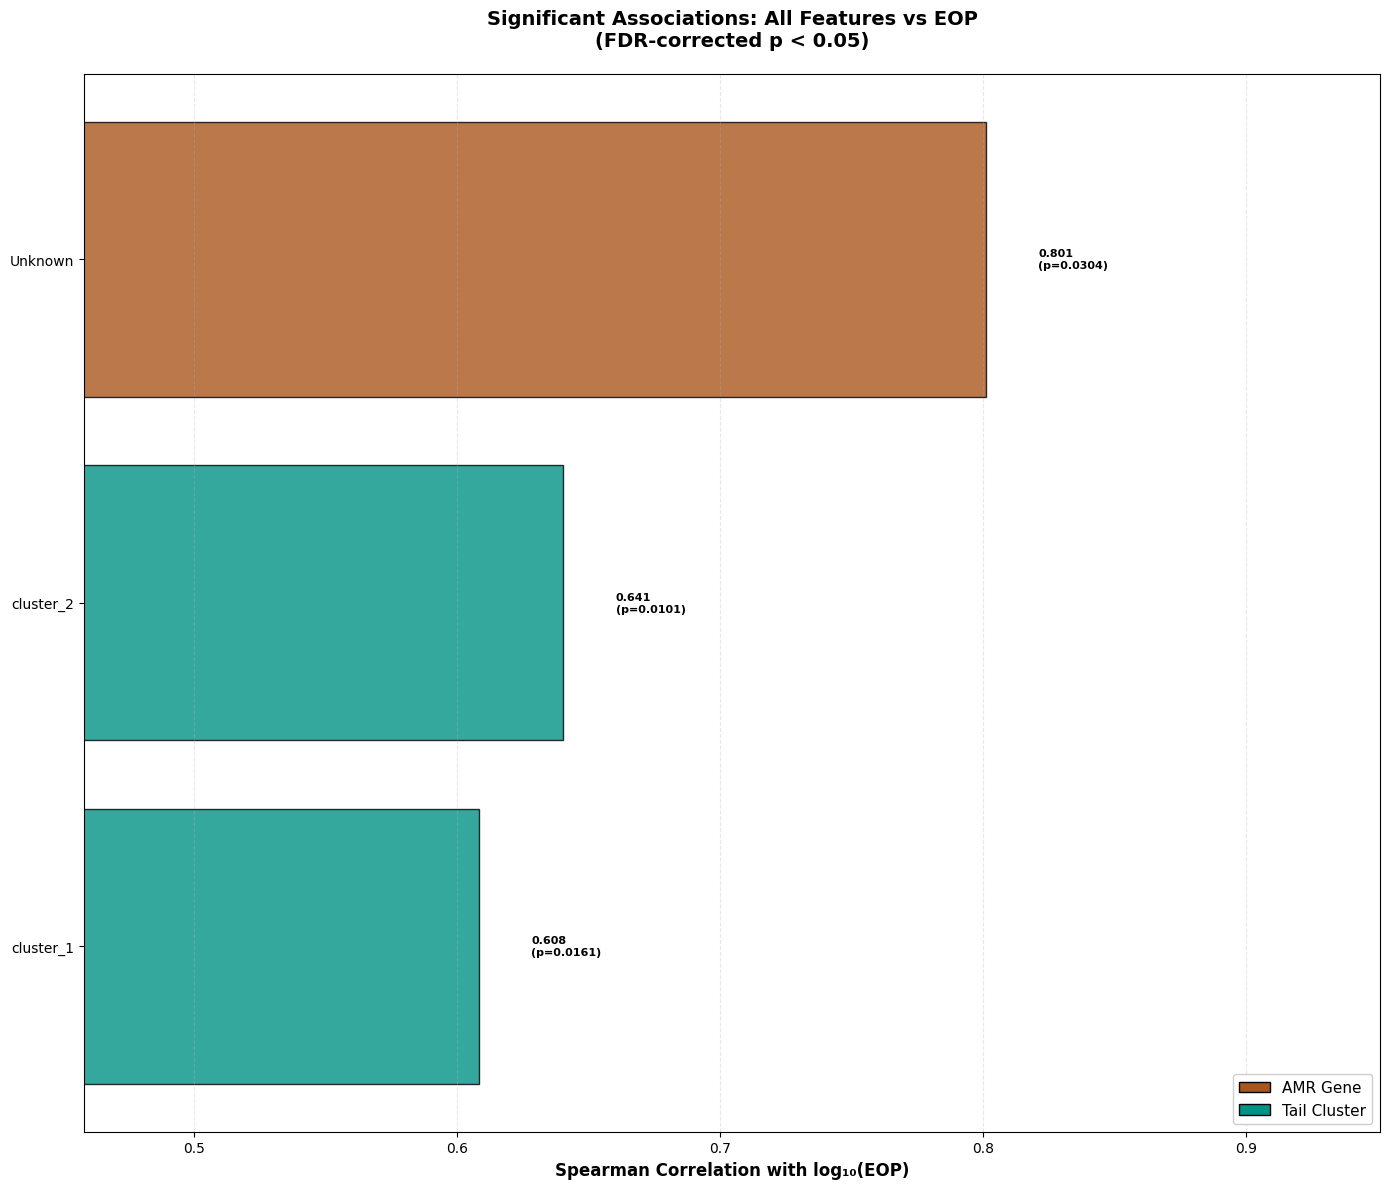

In [ ]:
import matplotlib.pyplot as plt

# Create main figure
fig1, ax1 = plot_all_significant_correlations(
    defense_corr_df=defense_corr_df_corr,
    amr_genes_corr_df=corr_df_corr,
    amr_phenotype_corr_df=corr_df_corr2,
    tail_cluster_corr_df=cluster_corr_df_corr,
    p_threshold=0.05,
    save_path='Fig_AllCorrelations.png'
)

plt.show()

Saved: Fig_CorrelationsSummary.png


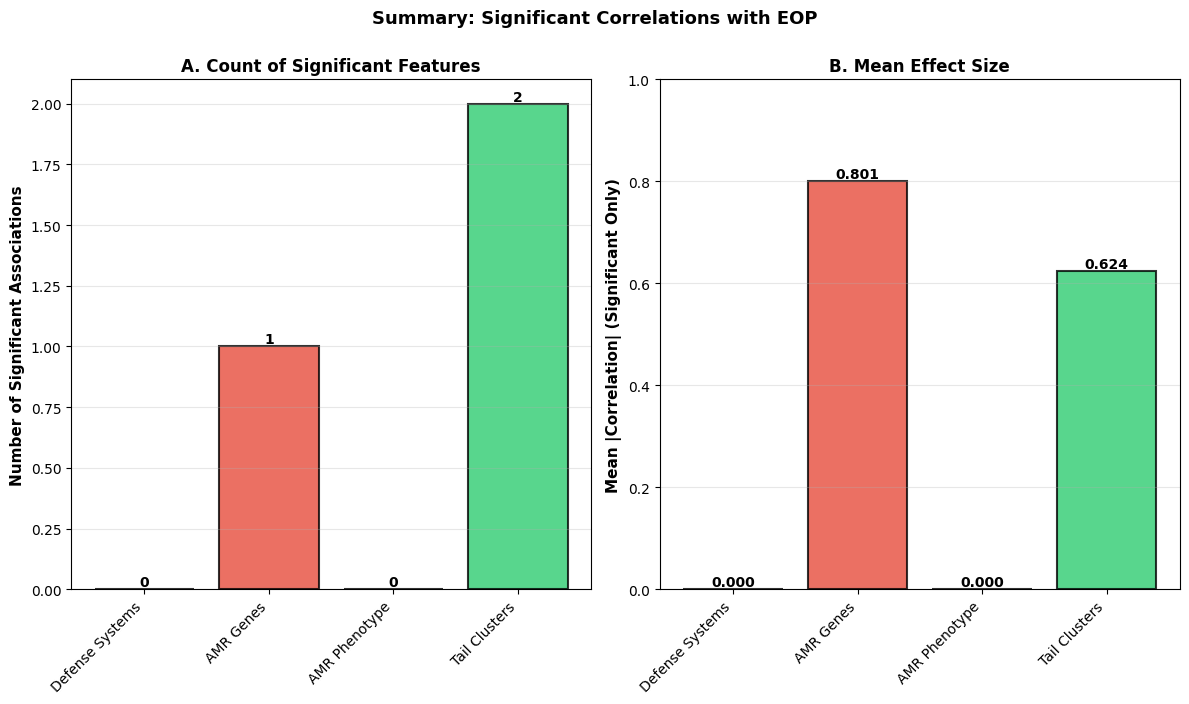

In [ ]:
defense_corr_df_corr = defense_corr_df_corr.rename(columns={'p': 'p_value', 'rho': 'spearman_rho'})
corr_df_corr = corr_df_corr.rename(columns={'rho': 'spearman_rho'})
corr_df_corr2 = corr_df_corr2.rename(columns={'rho': 'spearman_rho'})

fig2, (ax1, ax2) = plot_correlations_by_type(
     defense_corr_df=defense_corr_df_corr,
    amr_genes_corr_df=corr_df_corr,
    amr_phenotype_corr_df=corr_df_corr2,
    tail_cluster_corr_df=cluster_corr_df_corr,
    save_path='Fig_CorrelationsSummary.png'
)

plt.show()